<a href="https://colab.research.google.com/github/tyrashark/Course/blob/main/CSC535/CSC535_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<h1>CSC 535 — Homework 2</h1>  
<b>September 15, 2025</b>  
<br>  
<b>Sungmin Ji</b>

</div>

# Problem 1

## a)

Let $X \in \mathbb R^D $ be a Gaussian random variable with $\mu \in \mathbb R^D,~\Sigma \succeq 0_{D\times D}$ as a mean vector and a covariance matrix. The Gaussian PDF is given:
$$
p(\mathbf x) = \det(2\pi\Sigma)^{-1/2} \exp\left(-\frac{1}{2}(\mathbf x-\mu)^\top \Sigma^{-1} (\mathbf x- \mu) \right),\quad \mathbf x \in \mathbb R^D
$$

Consider a bivariate Gaussian PDF with $D=2,~\mu=(0,0)^\top,~\Sigma=\begin{bmatrix}0.5 & 0.8\\ 0.8 & 2\\\end{bmatrix}$. We generate a random number with $\texttt{Python}$ Code.

In [20]:
import math

# Parameters
mu = [0,0]
sigma = ((0.5, 0.8),
          (0.8, 2.0))

# Construct the Gaussian PDF

def gaussian_bivariate_pdf(x, mu, Sigma):
    """
    grid:  (n, n, 2) array where grid[..., 0] = x1 grid, grid[..., 1] = x2 grid
    mu:    (mu1, mu2)
    Sigma: ((a, b), (b, d)) covariance (must be PD)
    returns: (n, n) array with pdf values at each (x1, x2)
    """
    # Unpack Sigma and compute determinant/inverse
    a, b = Sigma[0]
    c, d = Sigma[1]
    det = a * d - b * c
    if det <= 0:
        raise ValueError("Covariance matrix must be positive definite (det > 0).")
    inv00 =  d / det
    inv01 = -b / det   # equals inv10
    inv11 =  a / det

    # Normalization coefficient
    coef = 1.0 / math.sqrt((2.0 * math.pi) ** 2 * det)

    # Deltas on the grid
    if isinstance(x, (tuple, list)) and len(x) == 2:
        X1, X2 = np.asarray(x[0]), np.asarray(x[1])
        dx1 = X1 - mu[0]
        dx2 = X2 - mu[1]
    else:
        arr = np.asarray(x)
        if arr.ndim == 1 and arr.shape == (2,):
            dx1 = arr[0] - mu[0]
            dx2 = arr[1] - mu[1]
        elif arr.ndim >= 1 and arr.shape[-1] == 2:
            dx1 = arr[..., 0] - mu[0]
            dx2 = arr[..., 1] - mu[1]
        else:
            raise ValueError("Input x must be (X, Y), a (...,2) array, or a 2-vector.")

    # Quadratic form: (x-mu)^T Sigma^{-1} (x-mu)
    q = inv00 * dx1 * dx1 + 2.0 * inv01 * dx1 * dx2 + inv11 * dx2 * dx2

    # PDF
    return coef * np.exp(-0.5 * q)

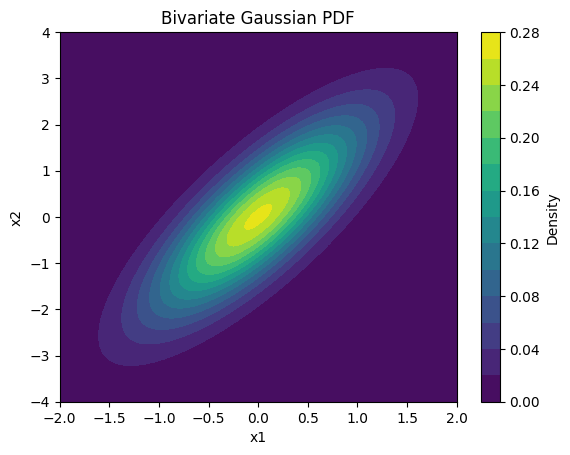

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Build an n x n x 2 tensor grid
delta = 0.05
x_seq = np.arange(-2.0, 2.0 + delta, delta)  # n1
y_seq = np.arange(-4.0, 4.0 + delta, delta)  # n2
X, Y = np.meshgrid(x_seq, y_seq, indexing='xy')
grid = np.stack([X, Y], axis=-1)             # Tensor dimension: (n1, n2, 2)

Z = gaussian_bivariate_pdf(grid, mu, sigma)

plt.contourf(X, Y, Z, levels=15)
plt.xlabel("x1")
plt.ylabel("x2")

# Colorbar with label for "Z"
cbar = plt.colorbar()
cbar.set_label("Density")
plt.title("Bivariate Gaussian PDF")
plt.show()

## b)
Find the Riemann sum to approximate the marginal densities of $X_1$ and $X_2$:  

$$
p(x_1) = \int_{\mathbb{R}} p(x_1, x_2)\, dx_2
= \frac{1}{\sqrt{2\pi \cdot 0.5}}
\exp\!\left(-\frac{x_1^2}{2 \cdot 0.5}\right),
\quad x_1 \in \mathbb{R}.
$$

$$
p(x_2) = \int_{\mathbb{R}} p(x_1, x_2)\, dx_1
= \frac{1}{\sqrt{2\pi \cdot 2}}
\exp\!\left(-\frac{x_2^2}{2 \cdot 2}\right),
\quad x_2 \in \mathbb{R}.
$$

These results show that $X_1$ and $X_2$ each follow Gaussian distributions with mean zero and variances $0.5$ and $2$, respectively.

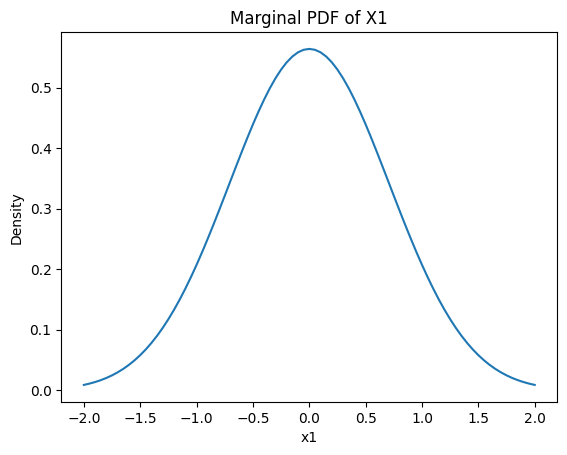

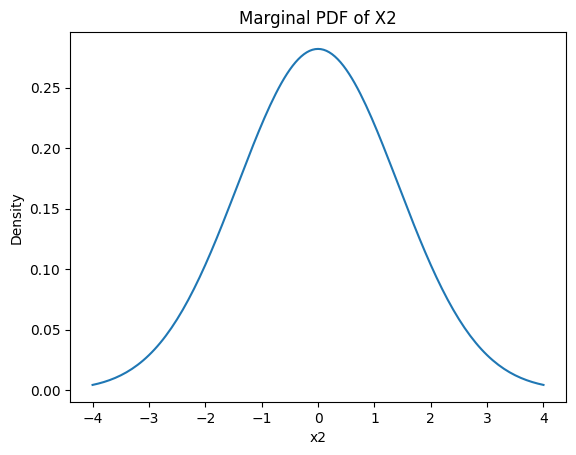

In [17]:
# Integrate by the Reimann Sum Approximation to find a Marginal PDF

def gaussian_marginal_pdf(grid, mu, Sigma, delt, check_x1=True):
  Z = gaussian_bivariate_pdf(grid, mu, Sigma)
  if check_x1:
        # Integrate along axis=0 (columns), keep x1
        marg = np.sum(Z, axis=0) * delta
  else:
        # Integrate along axis=1 (rows), keep x2
        marg = np.sum(Z, axis=1) * delta
  return marg

x1_marginal = gaussian_marginal_pdf(grid, mu, sigma, delta, check_x1=True)
x2_marginal = gaussian_marginal_pdf(grid, mu, sigma, delta, check_x1=False)

# Plot marginal of X1
plt.plot(x_seq, x1_marginal)
plt.xlabel("x1")
plt.ylabel("Density")
plt.title("Marginal PDF of X1")
plt.show()

# Plot marginal of X2
plt.plot(y_seq, x2_marginal)
plt.xlabel("x2")
plt.ylabel("Density")
plt.title("Marginal PDF of X2")
plt.show()


## c)

The conditional PDF of $X_1$ given $X_2 =2.0$ is
$$
p(x_1 \mid x_2)
= \frac{p(x_1, x_2)}{p(x_2)}
= \frac{1}{\sqrt{2\pi\,\sigma_{1|2}^2}}
\exp\!\left(
  -\frac{\big(x_1 - \mu_{1|2}\big)^2}{2\sigma_{1|2}^2}
\right),
\quad x_1 \in \mathbb{R},
$$

where  
$$
\mu_{1|2} = \mu_1 + \frac{\sigma_{12}}{\sigma_2^2}\,(x_2 - \mu_2) = \frac{0.8}{2}\cdot 2 = 0.8,
\qquad
\sigma_{1|2}^2 = \sigma_1^2 - \frac{\sigma_{12}^2}{\sigma_2^2} = 0.5 - \frac{0.8^2}{2}=0.18.
$$

This follows a Gaussian distribution with mean $0.8$ and variances $0.18$.

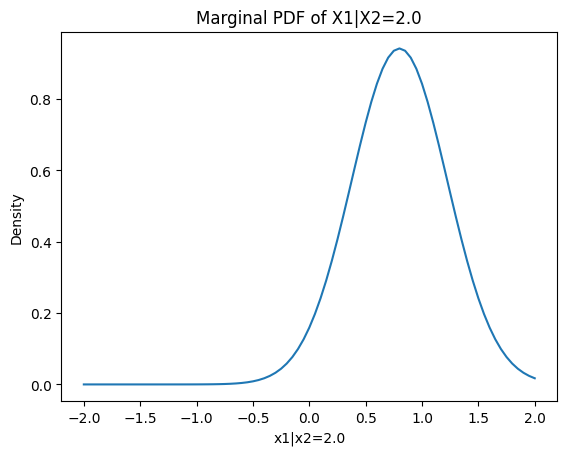

In [18]:
# Build an n x 1 x 2 tensor grid
delta = 0.05
x_seq = np.arange(-2.0, 2.0 + delta, delta)
X, Y = np.meshgrid(x_seq, 2, indexing='xy')
grid2 = np.stack([X, Y], axis=-1)

x2_marginal_2 = gaussian_marginal_pdf(grid2, mu, sigma, delta, check_x1=False)
Z2 = gaussian_bivariate_pdf(grid2, mu, sigma)[0]/x2_marginal_2

# Plot marginal of X1
plt.plot(x_seq, Z2)
plt.xlabel("x1|x2=2.0")
plt.ylabel("Density")
plt.title("Marginal PDF of X1|X2=2.0")
plt.show()


# Problem 2

## a)

Let $S \in \{T, F\}$ be the event that a randomly selected individual has COVID-19 antibodies, and let $R \in \{T, F\}$ be the test result.

According to the problem:
$$
\mathbb P(S=T)=\frac{1}{20},\quad
\mathbb P(R=T\mid S=T)=\frac{39}{40},\quad
\mathbb P(R=F\mid S=F)=\frac{991}{1000}.
$$

By conditional probability and the law of total probability:
$$
\mathbb P(R=T,S=T)=\mathbb P(R=T\mid S=T)\,\mathbb P(S=T)=\frac{39}{800}
$$
$$
\mathbb P(R=F,S=T)=\mathbb P(S=T)-\mathbb P(R=T,S=T)=\frac{1}{800}
$$
$$
\mathbb P(R=F,S=F)=\mathbb P(R=F\mid S=F)\,\mathbb P(S=F)=\frac{991\cdot 19}{1000\cdot 20}
$$
$$
\mathbb P(R=T,S=F)=\mathbb P(S=F)-\mathbb P(R=F,S=F)=\frac{9\cdot 19}{1000\cdot 20}
$$

## b)

By Bayes’ rule,
$$
\mathbb P(S=T\mid R=T)
= \frac{\mathbb P(R=T,S=T)}{\mathbb P(R=T,S=T)+\mathbb P(R=T,S=F)}
= \frac{\frac{39}{800}}{\frac{39}{800}+\frac{9\cdot 19}{1000\cdot 20}}
$$
$$
= \frac{975}{975+171} = \frac{975}{1146} = \frac{325}{382} \approx 0.8508
$$

## c)

By Bayes’ rule,
$$
\mathbb P(S=F\mid R=F)
= \frac{\mathbb P(R=F,S=F)}{\mathbb P(R=F,S=F)+\mathbb P(R=F,S=T)}
= \frac{\frac{991\cdot 19}{1000\cdot 20}}{\frac{991\cdot 19}{1000\cdot 20}+\frac{1}{800}}
$$
$$
= \frac{991\cdot 19}{991\cdot 19 + 25} \approx 0.9987
$$

## d)

Assuming two independent tests $R_1,R_2$ (conditionally independent given $S$):
$$
\mathbb P(S=T\mid R_1=T,R_2=T)
= \frac{\mathbb P(R=T\mid S=T)^2\,\mathbb P(S=T)}
{\mathbb P(R=T\mid S=T)^2\,\mathbb P(S=T)+\mathbb P(R=T\mid S=F)^2\,\mathbb P(S=F)}
$$
$$
= \frac{\left(\frac{39}{40}\right)^2 \cdot \frac{1}{20}}
{\left(\frac{39}{40}\right)^2 \cdot \frac{1}{20} + \left(\frac{9}{1000}\right)^2 \cdot \frac{19}{20}}
= \frac{39^2\cdot 25^2}{39^2\cdot 25^2 + 9^2\cdot 19} \approx 0.9984
$$

## e)

Now suppose $\mathbb P(S=T)=\frac{1}{100}$. Then
$$
\mathbb P(S=T\mid R=T)
= \frac{\frac{39}{40}\cdot \frac{1}{100}}
{\frac{39}{40}\cdot \frac{1}{100} + \frac{9}{1000}\cdot \frac{99}{100}}
= \frac{39\cdot 25}{39\cdot 25 + 9\cdot 99}
= \frac{325}{622} \approx 0.5225
$$


# Problem 3

## a)

We draw the bayes network representation of

$$
p(a,b,c) = p(c) p(a|c)p(b|c)
$$

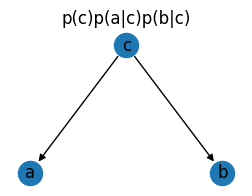

In [22]:
import networkx as nx

def draw_bn(edges, node_order=None, title="Bayesian Network"):

    G = nx.DiGraph()
    G.add_edges_from(edges)

    if node_order is not None:
        pos = {}
        y = 0.0
        for layer in node_order:
            xs = list(range(len(layer)))
            offset = -(len(layer) - 1) / 2.0
            for i, node in enumerate(layer):
                pos[node] = (xs[i] + offset, -y)
            y += 1.2
    else:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(3, 2))
    nx.draw_networkx_nodes(G, pos)
    nx.draw_networkx_labels(G, pos)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', min_source_margin=10, min_target_margin=10)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Draw a Bayes network
draw_bn([("c", "a"), ("c", "b")], node_order=[["c"], ["a", "b"]], title="p(c)p(a|c)p(b|c)")


## b)

| A | B | C | p(A,B,C) |
|------|------|------|------|
|  0   |  0   |  0   |  $\frac{1}{2^3}$   |
|  1   |  0   |  0   |  $\frac{1}{2^3}$   |
|  0   |  1   |  0   |  $\frac{1}{2^3}$   |
|  1   |  1   |  0   |  $\frac{1}{2^3}$   |
|  0   |  0   |  1   |  $\frac{1}{2\cdot 10^2}$   |
|  1   |  0   |  1   |  $\frac{9}{2\cdot 10^2}$   |
|  0   |  1   |  1   |  $\frac{9}{2\cdot 10^2}$   |
|  1   |  1   |  1   |  $\frac{81}{2\cdot 10^2}$   |




## c)

By the law of total probability,

$$
p(a,b) = \sum_c p(a,b,c) = \begin{cases} \frac{13}{100},& a=0,~b=0\\ \frac{17}{100},& a=0, b=1,~(a=1, b=0)\\ \frac{53}{100},& a=1,~b=1 \end{cases}
$$

$$p(a) = \sum_{b,c} p(a,b,c) = \begin{cases} \frac{3}{10},& a=0\\ \frac{7}{10},& a=1\\\end{cases}$$

$$p(b) = \sum_{a,c} p(a,b,c) = \begin{cases} \frac{3}{10},& b=0\\ \frac{7}{10},& b=1\\\end{cases}$$

Hence,
$$
p(a)p(b) = \begin{cases} \frac{9}{100},& a=0,~b=0\\ \frac{21}{100},&  a=0, b=1,~(a=1, b=0)\\ \frac{49}{100},& a=1,~b=1 \end{cases} \neq p(a,b)
$$

This contradicts $a \perp b \implies p(a)p(b) = p(a,b)$. Therefore, $a \not\perp b$.

# Problem 4

Show whether or not i) $C \perp B \mid D$ and ii) $E \perp C \mid B$.

## a)

$$
p(A,B,C,D,E) = p(A \mid D,E)\,p(B \mid D)\,p(C)\,p(D \mid C)\,p(E)
$$

i) Since $C \to D \to B$, where $D$ is a mediator between $C$ and $B$, conditioning on $D$ blocks the path between $C$ and $B$. Thus, it is true.

ii) $E$ and $C$ are already d-separated, and the path through $B$ does not connect to $E$. Thus, it is true.




## b)

$$
p(A,B,C,D,E) = p(A \mid C)\,p(E \mid B)\,p(C)\,p(B)\,p(D \mid A,E)
$$

i) The path $C \to A \to D \leftarrow E \leftarrow B$ has $D$ as a collider between $C$ and $B$. Conditioning on $D$ opens this path, so $C$ and $B$ are no longer independent given $D$. Thus, it is false.

ii) $E$ and $C$ are originally d-separated, and conditioning on $B$ does not open any new path. Thus, it is true.


## c)

$$
p(A,B,C,D,E) = p(C \mid A,B,D,E)\,p(A \mid B,D)\,p(D \mid B)\,p(B)\,p(E \mid A,B,D)
$$

i) Paths between $C$ and $B$ include  
- $C \leftarrow A \leftarrow B$,  
- $C \leftarrow A \leftarrow D \leftarrow B$,  
- $C \leftarrow D \leftarrow B$, as well as $C \leftarrow E \leftarrow D \leftarrow B$.  

Conditioning on $D$ blocks paths through $D$, but the indirect effect $B \to A \to C$ remains. Thus, it is false.

ii) $E$ has a direct edge into $C$, so $E$ and $C$ cannot be independent regardless of conditioning on $B$. Thus, it is false.


# Acknowledgement

I used generative AI (ChatGPT-5) to help amend structure, Python code, and LaTeX templates in this work, after solving the problems independently.